# Brain-Age Fairness Project 


## 1. Install only the packages required here

In [1]:
%pip -q install kaggle gdown xlrd openpyxl
print('Packages ready.')

Packages ready.


## 2. Configure a project location

In [ ]:
from pathlib import Path
import os
import shutil
import subprocess
import sys
import zipfile

USE_GOOGLE_DRIVE = True  
KAGGLE_AUTH_METHOD = 'upload'  

if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
    except ImportError as exc:
        raise RuntimeError('Google Drive mode is available only in Google Colab.') from exc
    drive.mount('/content/drive')
    PROJECT_DIR = Path('/content/drive/MyDrive/ML_Project')
else:
    PROJECT_DIR = Path('/content/ML_Project') if Path('/content').exists() else Path.cwd() / 'ML_Project'

DATA_DIR = PROJECT_DIR / 'IXI_data'
DOWNLOAD_DIR = PROJECT_DIR / 'downloads'
PROJECT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
DOWNLOAD_DIR.mkdir(parents=True, exist_ok=True)


project_kaggle_json = Path.cwd() / 'kaggle.json'
if project_kaggle_json.is_file():
    os.environ['KAGGLE_CONFIG_DIR'] = str(project_kaggle_json.parent)
    print(f'Using Kaggle credentials from {project_kaggle_json}.')
print(f'Project directory: {PROJECT_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/ML_Project


## 3. Set up Kaggle credentials

Put `kaggle.json` in the same folder as this notebook, then run the next cell. It does not upload anything or open a file chooser. The project `.gitignore` prevents the credential file from being committed.


In [ ]:
import os
import json
from pathlib import Path

KAGGLE_USERNAME = "YOUR_USERNAME"
KAGGLE_KEY = "YOUR_KEY"

kaggle_dir = Path("/root/.config/kaggle")
kaggle_dir.mkdir(parents=True, exist_ok=True)

kaggle_file = kaggle_dir / "kaggle.json"

kaggle_file.write_text(json.dumps({
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_KEY
}))

kaggle_file.chmod(0o600)

os.environ["KAGGLE_CONFIG_DIR"] = str(kaggle_dir)

print("Kaggle credentials configured")

## 4. Check the existing dataset

In [ ]:
def is_t1_filename(name):
    return name.lower().endswith(('-t1.nii', '-t1.nii.gz'))

def find_t1_scans(root):
    return sorted(
        path for path in Path(root).rglob('*')
        if path.is_file() and (is_t1_filename(path.name) or is_t1_filename(path.parent.name))
    )

scan_paths = find_t1_scans(DATA_DIR)
print(f'Valid T1 scans already available: {len(scan_paths)}')
DATA_READY = len(scan_paths) >= 400

Valid T1 scans already available: 0


## 5. Download and extract the IXI T1 data when required

In [5]:
if not DATA_READY:
    archive = DOWNLOAD_DIR / 'ixi-t1.zip'
    extract_dir = DOWNLOAD_DIR / 'ixi-t1-extracted'

    archive_is_valid = archive.is_file() and zipfile.is_zipfile(archive)
    if not archive_is_valid or archive.stat().st_size < 1_000_000_000:
        print('Downloading the public Kaggle dataset. This is several GB and can take a while...')
        kaggle_config_dir = Path(os.environ.get('KAGGLE_CONFIG_DIR', Path.home() / '.kaggle'))
        kaggle_json = kaggle_config_dir / 'kaggle.json'
        kaggle_env_configured = bool(os.environ.get('KAGGLE_USERNAME') and os.environ.get('KAGGLE_KEY'))
        if not kaggle_json.is_file() and not kaggle_env_configured:
            raise FileNotFoundError(
                'Kaggle credentials are required. Create a token in Kaggle Settings → API → Create New Token, ' 
                f'then save it as {kaggle_json}, or set KAGGLE_USERNAME and KAGGLE_KEY.'
            )

        kaggle_command = shutil.which('kaggle')
        if not kaggle_command:
            raise RuntimeError('The Kaggle CLI was not installed. Re-run the package-install cell, then retry.')

        result = subprocess.run(
            [kaggle_command, 'datasets', 'download', '-d', 'kbacon/ixi-t1',
             '-p', str(DOWNLOAD_DIR), '--force'],
            text=True, capture_output=True
        )
        if result.returncode:
            raise RuntimeError(
                'Kaggle download failed. Confirm the token is valid, you have accepted any dataset rules, ' 
                'and internet access is available.\n' + (result.stderr or result.stdout)[-2000:]
            )

    zip_candidates = sorted(
        (path for path in DOWNLOAD_DIR.glob('*.zip') if zipfile.is_zipfile(path)),
        key=lambda path: path.stat().st_size,
        reverse=True,
    )
    if not zip_candidates:
        raise zipfile.BadZipFile('Kaggle did not produce a valid ZIP archive. Re-run this cell to download it again.')
    archive = zip_candidates[0]
    print(f'Using archive: {archive.name} ({archive.stat().st_size / 1e9:.2f} GB)')

    if not extract_dir.exists() or not any(extract_dir.rglob('*.nii*')):
        extract_dir.mkdir(parents=True, exist_ok=True)
        print('Extracting archive...')
        with zipfile.ZipFile(archive) as zf:
            zf.extractall(extract_dir)

    extracted_scans = find_t1_scans(extract_dir)
    if len(extracted_scans) < 400:
        all_nifti_entries = sorted(extract_dir.rglob('*.nii*'))
        nifti_files = [path for path in all_nifti_entries if path.is_file()]
        t1_named_entries = [path for path in all_nifti_entries if 'T1' in path.name.upper()]
        t1_directories = [path for path in t1_named_entries if path.is_dir()]
        print(f'Diagnostic: {len(all_nifti_entries)} .nii entries; {len(nifti_files)} are real files; {len(t1_directories)} T1-named entries are folders; {len(extracted_scans)} are exact T1 files.')
        print('Example .nii entry names:', [path.name for path in all_nifti_entries[:10]])
        if t1_directories:
            sample_folder = t1_directories[0]
            sample_contents = [str(path.relative_to(sample_folder)) for path in sorted(sample_folder.rglob('*'))[:10]]
            print(f'Inside {sample_folder.name}:', sample_contents)
        raise RuntimeError(f'Only {len(extracted_scans)} valid T1 scans were extracted; expected at least 400.')

    print(f'Copying {len(extracted_scans)} verified scans into {DATA_DIR}...')
    for source in extracted_scans:
        destination_name = source.parent.name if is_t1_filename(source.parent.name) else source.name
        destination = DATA_DIR / destination_name
        if not destination.exists() or destination.stat().st_size != source.stat().st_size:
            shutil.copy2(source, destination)

scan_paths = find_t1_scans(DATA_DIR)
if len(scan_paths) < 400:
    raise RuntimeError(f'Dataset validation failed: found {len(scan_paths)} valid T1 scans.')
print(f'Dataset ready: {len(scan_paths)} valid T1 scans.')

Using archive: ixi-t1.zip (4.88 GB)
Copying 581 verified scans into /content/drive/MyDrive/ML_Project/IXI_data...
Dataset ready: 581 valid T1 scans.


## 6. Build the scan index

In [6]:
import re
import pandas as pd

records = []
pattern = re.compile(r'IXI(?P<id>\d+)-(?P<site>[^-]+)-.*T1', re.IGNORECASE)
for path in scan_paths:
    match = pattern.search(path.name)
    if match:
        records.append({
            'IXI_ID': int(match.group('id')),
            'site': match.group('site'),
            'filename': path.name,
            'file_path': str(path),
        })

df_files = pd.DataFrame(records).drop_duplicates('IXI_ID').sort_values('IXI_ID').reset_index(drop=True)
if df_files.empty:
    raise RuntimeError('No scan names matched the expected IXI###-Site-...-T1 format.')
print(f'Indexed {len(df_files)} unique subjects.')
df_files.head()

Indexed 581 unique subjects.


,IXI_ID,site,filename,file_path
0,2,Guys,IXI002-Guys-0828-T1.nii,/content/drive/MyDrive/ML_Project/IXI_data/IXI...
1,12,HH,IXI012-HH-1211-T1.nii,/content/drive/MyDrive/ML_Project/IXI_data/IXI...
2,13,HH,IXI013-HH-1212-T1.nii,/content/drive/MyDrive/ML_Project/IXI_data/IXI...
3,14,HH,IXI014-HH-1236-T1.nii,/content/drive/MyDrive/ML_Project/IXI_data/IXI...
4,15,HH,IXI015-HH-1258-T1.nii,/content/drive/MyDrive/ML_Project/IXI_data/IXI...


## 7. Download and validate demographics

In [ ]:
DEMO_FILE_ID = '168-gI32bk0BHbXJYghaLx1YoHQKDUTKr'
demo_path = PROJECT_DIR / 'IXI_demographics.xls'

if not demo_path.exists() or demo_path.stat().st_size < 5_000:
    result = subprocess.run(
        [sys.executable, '-m', 'gdown', '--id', DEMO_FILE_ID, '-O', str(demo_path)],
        text=True, capture_output=True
    )
    if result.returncode:
        raise RuntimeError('Demographics download failed.\n' + result.stderr[-2000:])

if not demo_path.exists() or demo_path.stat().st_size < 5_000:
    raise RuntimeError('Demographics file is missing or suspiciously small.')


with demo_path.open('rb') as file_handle:
    file_signature = file_handle.read(8)

if file_signature.startswith(b'\xd0\xcf\x11\xe0'):
    df_meta_raw = pd.read_excel(demo_path, engine='xlrd')
elif file_signature.startswith(b'PK'):
    df_meta_raw = pd.read_excel(demo_path, engine='openpyxl')
else:
    df_meta_raw = pd.read_csv(demo_path, sep=None, engine='python', encoding='utf-8-sig')
print(f'Loaded demographics: {df_meta_raw.shape}')
print(df_meta_raw.columns.tolist())

Loaded demographics: (587, 12)
['Subject_ID', 'SEX_ID (1=m, 2=f)', 'HEIGHT', 'WEIGHT', 'ETHNIC_ID', 'MARITAL_ID', 'OCCUPATION_ID', 'QUALIFICATION_ID', 'DOB', 'DATE_AVAILABLE', 'STUDY_DATE', 'AGE']


## 8. Merge, save, and summarize

In [10]:
required_indices = [0, 1, 11]
if df_meta_raw.shape[1] <= max(required_indices):
    raise ValueError('The demographics spreadsheet has an unexpected layout.')

df_meta = df_meta_raw.iloc[:, required_indices].copy()
df_meta.columns = ['IXI_ID', 'SEX', 'AGE']
df_meta['IXI_ID'] = pd.to_numeric(df_meta['IXI_ID'], errors='coerce')
df_meta['AGE'] = pd.to_numeric(df_meta['AGE'], errors='coerce')
df_meta = df_meta.dropna(subset=['IXI_ID', 'AGE']).copy()
df_meta['IXI_ID'] = df_meta['IXI_ID'].astype(int)
df_meta = df_meta.drop_duplicates('IXI_ID')

final_df = pd.merge(df_files, df_meta, on='IXI_ID', how='inner')
final_df['sex_label'] = final_df['SEX'].map({1: 'Male', 2: 'Female'}).fillna('Unknown')
if final_df.empty:
    raise RuntimeError('The scan index and demographics did not produce any matching subjects.')

metadata_path = PROJECT_DIR / 'ixi_final_metadata.csv'
final_df.to_csv(metadata_path, index=False)
print(f'Saved {len(final_df)} matched subjects to {metadata_path}')
print(f'Age range: {final_df.AGE.min():.1f}–{final_df.AGE.max():.1f} years; mean: {final_df.AGE.mean():.1f}')
print(final_df.groupby(['site', 'sex_label']).size().unstack(fill_value=0))

Saved 499 matched subjects to /content/drive/MyDrive/ML_Project/ixi_final_metadata.csv
Age range: 20.0–86.3 years; mean: 48.8
sex_label  Female  Male
site                   
Guys          156   126
HH             84    66
IOP            38    29


## 9. Create a dataset overview

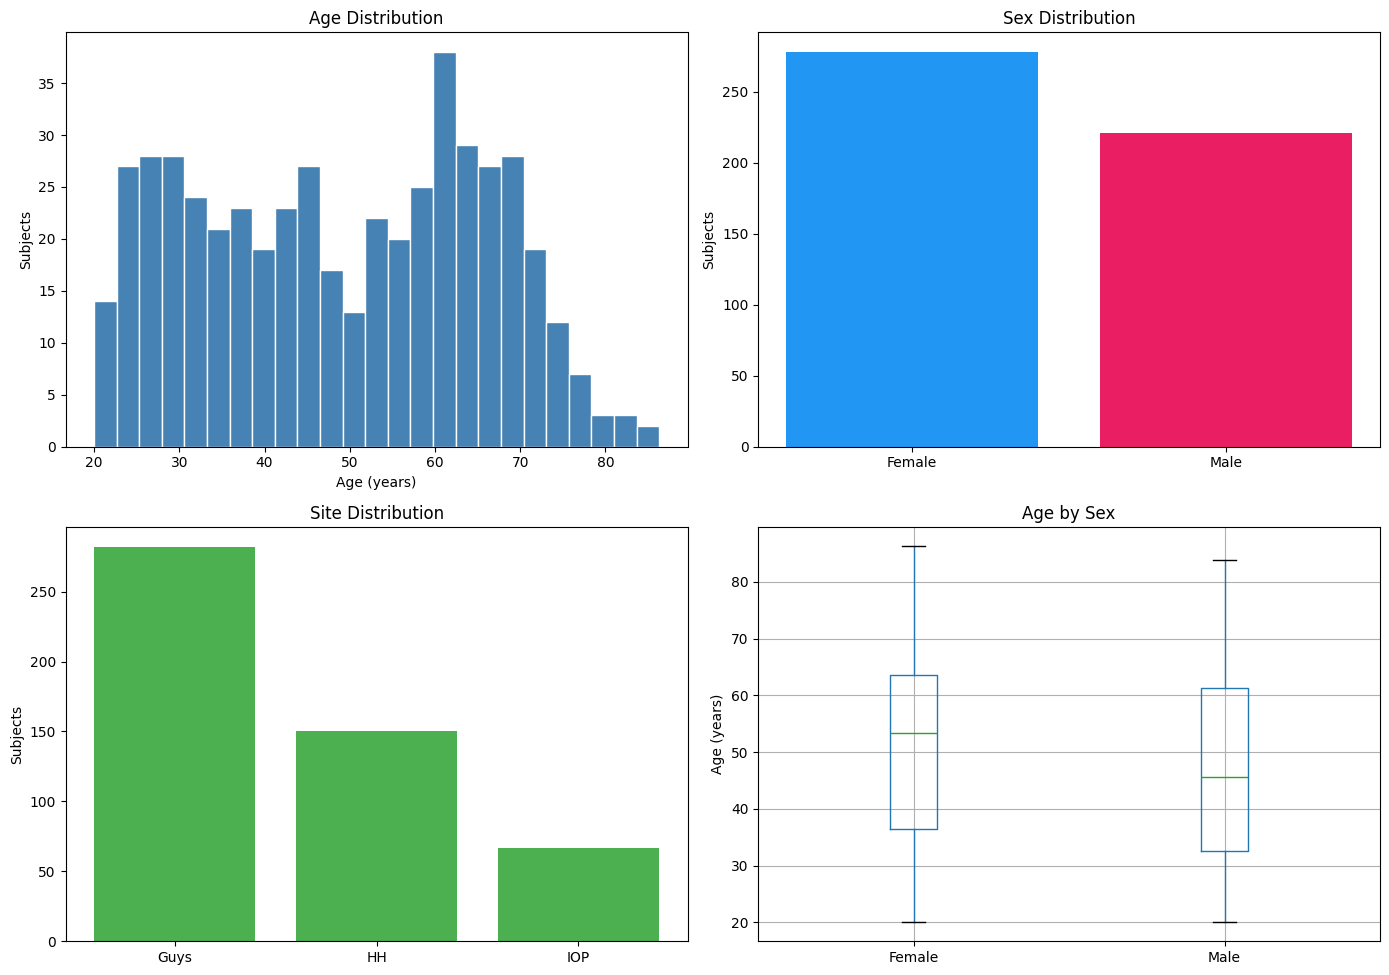

Completed successfully. Summary plot saved to /content/drive/MyDrive/ML_Project/phase1_final_summary.png


In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Final IXI Dataset', fontsize=16, fontweight='bold')

axes[0, 0].hist(final_df['AGE'], bins=25, color='steelblue', edgecolor='white')
axes[0, 0].set(title='Age Distribution', xlabel='Age (years)', ylabel='Subjects')

sex_counts = final_df['sex_label'].value_counts()
axes[0, 1].bar(sex_counts.index, sex_counts.values, color=['#2196F3', '#E91E63', '#9E9E9E'][:len(sex_counts)])
axes[0, 1].set(title='Sex Distribution', ylabel='Subjects')

site_counts = final_df['site'].value_counts()
axes[1, 0].bar(site_counts.index, site_counts.values, color='#4CAF50')
axes[1, 0].set(title='Site Distribution', ylabel='Subjects')

final_df.boxplot(column='AGE', by='sex_label', ax=axes[1, 1])
axes[1, 1].set(title='Age by Sex', xlabel='', ylabel='Age (years)')
plt.suptitle('')
plt.tight_layout()

plot_path = PROJECT_DIR / 'phase1_final_summary.png'
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Completed successfully. Summary plot saved to {plot_path}')